<a href="https://colab.research.google.com/github/chrisseub/ML-Practice-Rep/blob/main/UPDATED_FOR_EXTERNAL_TRAITS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#IMPORT THE LIBRARIES

In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_squared_error, r2_score, classification_report, balanced_accuracy_score, roc_auc_score, ConfusionMatrixDisplay
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

#IMPORT THE EGG QUALITY DATA

In [23]:
Egg_Traits = pd.read_excel('/content/main.xls')

#VIEWING THE DATA
print(Egg_Traits.head())
Egg_Traits.shape

  STRAIN          AGE  EGG_WEIGHT   EGG_LENGTH  EGG_WIDTH YOLK_HEIGHT  \
0  BROWN  EARLY LAYER         52.5        5.75        4.0         1.8   
1  BROWN  EARLY LAYER         62.6        5.70        4.3           2   
2  BROWN  EARLY LAYER         61.0        5.50        4.3         1.8   
3  BROWN  EARLY LAYER         64.1        5.70        4.4         1.9   
4  BROWN  EARLY LAYER         53.9        5.60        4.0         2.2   

  YOLK_WIDTH ALB_HEIGHT  YOLK _ALB_WEIGHT   SHELL_WEIGTH  SHELL_THICKNESS  \
0        4.1        0.7               48.0           5.9             0.27   
1        4.2        0.8               54.8           7.7             0.35   
2          4          1               53.5           7.5             0.35   
3          4          1               55.7           7.4             0.29   
4          4       0.65               46.0           7.0             0.39   

   Haugh Unit  Shell surface area  Yolk Index  Shape Index Outcome  
0   84.390042           63.77

(300, 16)

#ANALYSING THE DATA

In [24]:
Egg_Traits.describe()

,EGG_WEIGHT,EGG_LENGTH,EGG_WIDTH,YOLK _ALB_WEIGHT,SHELL_WEIGTH,SHELL_THICKNESS,Haugh Unit,Shell surface area,Yolk Index,Shape Index
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,299.000000,300.000000,296.000000,300.000000
mean,63.848667,5.800800,4.340500,55.607333,7.593667,0.323033,84.539822,72.483645,48.002424,75.555584
std,6.304399,0.306651,0.291033,5.840976,0.704686,0.042691,0.744175,4.739732,4.481038,5.981744
min,49.700000,5.100000,0.300000,43.000000,5.900000,0.200000,81.801110,61.505237,21.621622,5.263158
25%,59.200000,5.587500,4.200000,51.300000,7.100000,0.290000,84.057052,69.031801,45.238095,73.098388
50%,63.650000,5.800000,4.300000,55.500000,7.500000,0.330000,84.548793,72.414210,47.619048,75.545385
75%,68.600000,6.000000,4.500000,60.350000,8.025000,0.350000,85.045960,76.083555,50.166667,78.181818
max,78.900000,7.000000,4.900000,70.200000,9.900000,0.420000,86.421165,83.442576,61.764706,89.090909


In [25]:
Egg_Traits['Outcome'].value_counts()

,count
Outcome,
Large,229
Small,71


In [26]:
numeric_columns = Egg_Traits.select_dtypes(include=np.number).columns
Egg_Traits.groupby('Outcome')[numeric_columns].mean()

,EGG_WEIGHT,EGG_LENGTH,EGG_WIDTH,YOLK _ALB_WEIGHT,SHELL_WEIGTH,SHELL_THICKNESS,Haugh Unit,Shell surface area,Yolk Index,Shape Index
Outcome,,,,,,,,,,
Large,66.427948,5.890349,4.392140,57.916594,7.759825,0.317031,84.428646,74.443886,47.850931,74.856325
Small,55.529577,5.511972,4.173944,48.159155,7.057746,0.342394,84.896838,66.161177,48.510369,77.810941


In [27]:
Outcome_mapping = {'Small': 0, 'Large': 1}
Egg_Traits['Outcome_Numeric'] = Egg_Traits['Outcome'].map(Outcome_mapping)
print(Egg_Traits.head())

  STRAIN          AGE  EGG_WEIGHT   EGG_LENGTH  EGG_WIDTH YOLK_HEIGHT  \
0  BROWN  EARLY LAYER         52.5        5.75        4.0         1.8   
1  BROWN  EARLY LAYER         62.6        5.70        4.3           2   
2  BROWN  EARLY LAYER         61.0        5.50        4.3         1.8   
3  BROWN  EARLY LAYER         64.1        5.70        4.4         1.9   
4  BROWN  EARLY LAYER         53.9        5.60        4.0         2.2   

  YOLK_WIDTH ALB_HEIGHT  YOLK _ALB_WEIGHT   SHELL_WEIGTH  SHELL_THICKNESS  \
0        4.1        0.7               48.0           5.9             0.27   
1        4.2        0.8               54.8           7.7             0.35   
2          4          1               53.5           7.5             0.35   
3          4          1               55.7           7.4             0.29   
4          4       0.65               46.0           7.0             0.39   

   Haugh Unit  Shell surface area  Yolk Index  Shape Index Outcome  \
0   84.390042           63.7

#DROPPING FEATURES

In [28]:
X = Egg_Traits.drop(columns=[Egg_Traits.columns[2], 'STRAIN', 'AGE', 'Outcome', 'Outcome_Numeric', 'Shell surface area'], axis=1)
Y = Egg_Traits['Outcome_Numeric']

X.columns = X.columns.str.strip()

print("Columns in X before dropping:", X.columns.tolist())

columns_to_drop = ['YOLK_HEIGHT', 'YOLK_WIDTH', 'ALB_HEIGHT', 'YOLK _ALB_WEIGHT', 'SHELL_WEIGTH', 'SHELL_THICKNESS', 'Haugh Unit', 'Yolk Index']

adjusted_columns_to_drop = []
for col in columns_to_drop:
    if col == 'YOLK _ALB_WEIGHT':
        if 'YOLK _ALB_WEIGHT' not in X.columns.tolist() and 'YOLK_ALB_WEIGHT' in X.columns.tolist():
            adjusted_columns_to_drop.append('YOLK_ALB_WEIGHT')
            print("Note: 'YOLK _ALB_WEIGHT' not found, using 'YOLK_ALB_WEIGHT' instead.")
        else:
            adjusted_columns_to_drop.append(col)
    else:
        adjusted_columns_to_drop.append(col)

final_columns_to_drop = [col for col in adjusted_columns_to_drop if col in X.columns.tolist()]

if len(final_columns_to_drop) != len(columns_to_drop):
    print("Warning: Some columns specified for dropping were not found in the DataFrame. Only dropping existing columns.")
    print("Original columns to drop:", columns_to_drop)
    print("Final columns to drop:", final_columns_to_drop)

X = X.drop(columns=final_columns_to_drop, axis=1)
print("Columns dropped successfully. New shape of X:", X.shape)

print(X)
print(Y)

Columns in X before dropping: ['EGG_LENGTH', 'EGG_WIDTH', 'YOLK_HEIGHT', 'YOLK_WIDTH', 'ALB_HEIGHT', 'YOLK _ALB_WEIGHT', 'SHELL_WEIGTH', 'SHELL_THICKNESS', 'Haugh Unit', 'Yolk Index', 'Shape Index']
Columns dropped successfully. New shape of X: (300, 3)
     EGG_LENGTH  EGG_WIDTH  Shape Index
0          5.75       4.00    69.565217
1          5.70       4.30    75.438596
2          5.50       4.30    78.181818
3          5.70       4.40    77.192982
4          5.60       4.00    71.428571
..          ...        ...          ...
295        5.30       4.15    78.301887
296        5.65       4.25    75.221239
297        5.70       4.30    75.438596
298        5.60       4.20    75.000000
299        6.10       4.20    68.852459

[300 rows x 3 columns]
0      0
1      1
2      1
3      1
4      0
      ..
295    0
296    1
297    1
298    0
299    1
Name: Outcome_Numeric, Length: 300, dtype: int64


# SPLIT AND INPUT DATA


In [29]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

imputer = SimpleImputer(strategy='mean')

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

X_train = pd.DataFrame(X_train_imputed, columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_imputed, columns=X_test.columns, index=X_test.index)

print("Data re-split and re-imputed successfully.")

Data re-split and re-imputed successfully.


#LOGISTIC REGRESSION MODEL

In [30]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, Y_train)
print("Logistic Regression model re-trained successfully.")

Logistic Regression model re-trained successfully.


Logistic Regression Metrics (after removing internal egg quality traits):
Balanced Accuracy: 0.8913
ROC AUC Score: 0.9495

Classification Report:
              precision    recall  f1-score   support

           0       0.58      1.00      0.74        14
           1       1.00      0.78      0.88        46

    accuracy                           0.83        60
   macro avg       0.79      0.89      0.81        60
weighted avg       0.90      0.83      0.85        60


Confusion Matrix for Logistic Regression:


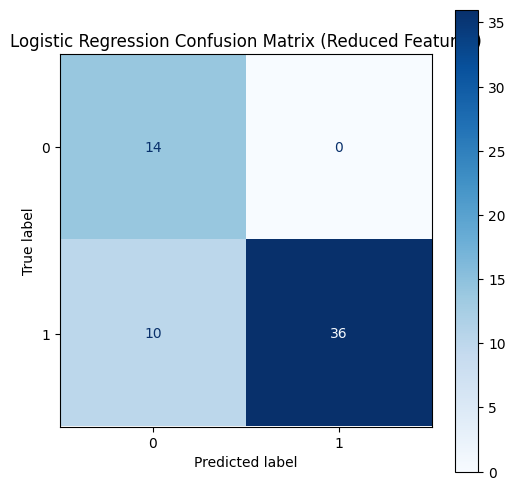

In [31]:
y_pred_lr = model.predict(X_test)

print("Logistic Regression Metrics (after removing internal egg quality traits):")
print(f"Balanced Accuracy: {balanced_accuracy_score(Y_test, y_pred_lr):.4f}")
print(f"ROC AUC Score: {roc_auc_score(Y_test, model.predict_proba(X_test)[:, 1]):.4f}")
print("\nClassification Report:")
print(classification_report(Y_test, y_pred_lr))

print("\nConfusion Matrix for Logistic Regression:")
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(model, X_test, Y_test, cmap='Blues', ax=ax)
plt.title('Logistic Regression Confusion Matrix (Reduced Features)')
plt.show()

MAKING A PREDICTION (LOGISTIC REGRESSION)

In [32]:
"""Features to be inputed are:
Egg length, Egg width, Shape index) accordingly"""

EGG_data = (5.6, 4.1, 73.2)
EGG_data_as_numpy_array = np.asarray(EGG_data)
EGG_data_reshaped = EGG_data_as_numpy_array.reshape(1, -1)

print("Prediction using Logistic Regression:")
prediction_lr = model.predict(EGG_data_reshaped)
print(prediction_lr)

if (prediction_lr[0] == 0):
  print('This egg is predicted as Small by Logistic Regression')
else:
  print('This egg is predicted as Large by Logistic Regression')

Prediction using Logistic Regression:
[0]
This egg is predicted as Small by Logistic Regression


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


## Feature Importance Analysis (Logistic Regression)

Feature Importances (Logistic Regression - based on coefficients):
       Feature  Absolute_Coefficient
1    EGG_WIDTH              4.243552
0   EGG_LENGTH              4.033759
2  Shape Index              0.016637


/tmp/ipython-input-189/1385184779.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Absolute_Coefficient', y='Feature', data=importance_lr_df, palette='viridis', legend=False)


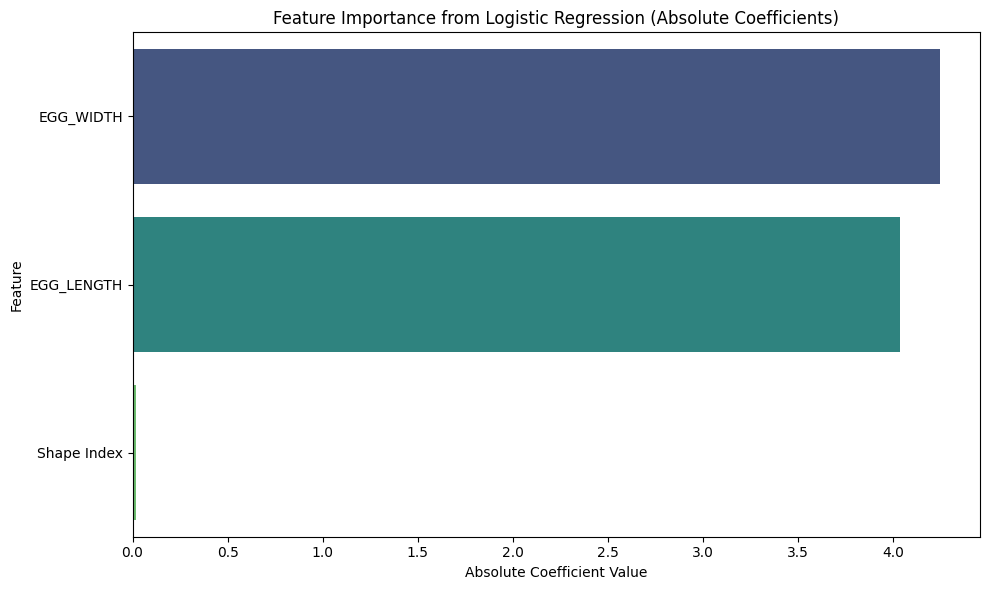

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get coefficients from the Logistic Regression model
coefficients = model.coef_[0]

# Get feature names from the training data
feature_names = X_train.columns

# Create a DataFrame for better visualization
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

# Calculate absolute coefficients for importance ranking
coef_df['Absolute_Coefficient'] = abs(coef_df['Coefficient'])

# Sort the features by absolute coefficient in descending order
importance_lr_df = coef_df.sort_values(by='Absolute_Coefficient', ascending=False)

print("Feature Importances (Logistic Regression - based on coefficients):")
print(importance_lr_df[['Feature', 'Absolute_Coefficient']])

# Plotting the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Absolute_Coefficient', y='Feature', data=importance_lr_df, palette='viridis', legend=False)
plt.title('Feature Importance from Logistic Regression (Absolute Coefficients)')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

#RANDOM FOREST MODEL

In [34]:
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
rf.fit(X_train, Y_train)
print("Random Forest model re-trained successfully.")

Random Forest model re-trained successfully.


Random Forest Metrics (after removing internal egg quality traits):
Balanced Accuracy: 0.8137
ROC AUC Score: 0.9340

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.71      0.71        14
           1       0.91      0.91      0.91        46

    accuracy                           0.87        60
   macro avg       0.81      0.81      0.81        60
weighted avg       0.87      0.87      0.87        60


Confusion Matrix for Random Forest:


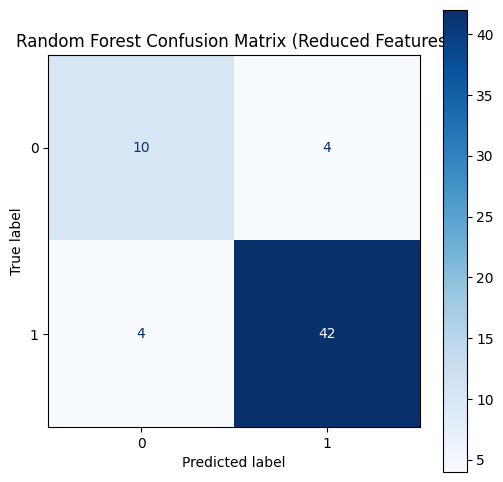

In [35]:
y_pred_rf = rf.predict(X_test)

print("Random Forest Metrics (after removing internal egg quality traits):")
print(f"Balanced Accuracy: {balanced_accuracy_score(Y_test, y_pred_rf):.4f}")
print(f"ROC AUC Score: {roc_auc_score(Y_test, rf.predict_proba(X_test)[:, 1]):.4f}")
print("\nClassification Report:")
print(classification_report(Y_test, y_pred_rf))

print("\nConfusion Matrix for Random Forest:")
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(rf, X_test, Y_test, cmap='Blues', ax=ax)
plt.title('Random Forest Confusion Matrix (Reduced Features)')
plt.show()

MAKING A PREDICTION (RANDOM FOREST)

In [36]:
"""Features to be inputed are:
Egg length, Egg width, Shape index) accordingly"""

EGG_data = (5.6, 4.1, 73.2)
EGG_data_as_numpy_array = np.asarray(EGG_data)
EGG_data_reshaped = EGG_data_as_numpy_array.reshape(1, -1)

print("\nPrediction using Random Forest:")
single_prediction_rf = rf.predict(EGG_data_reshaped)
print(single_prediction_rf)

if single_prediction_rf[0] == 0:
    print('This egg is predicted as Small by Random Forest')
else:
    print('This egg is predicted as Large by Random Forest')


Prediction using Random Forest:
[0]
This egg is predicted as Small by Random Forest


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


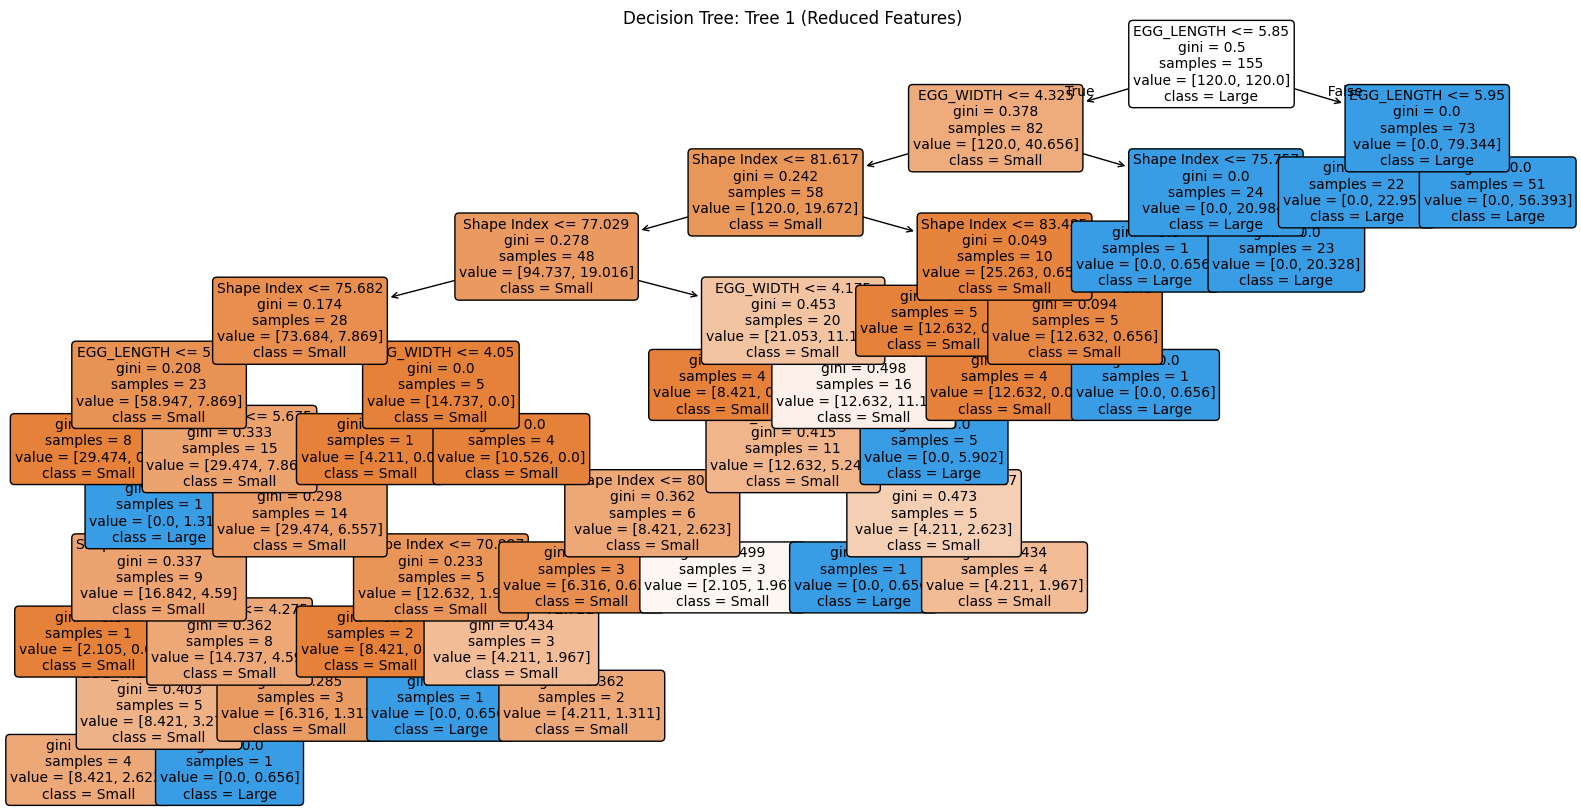

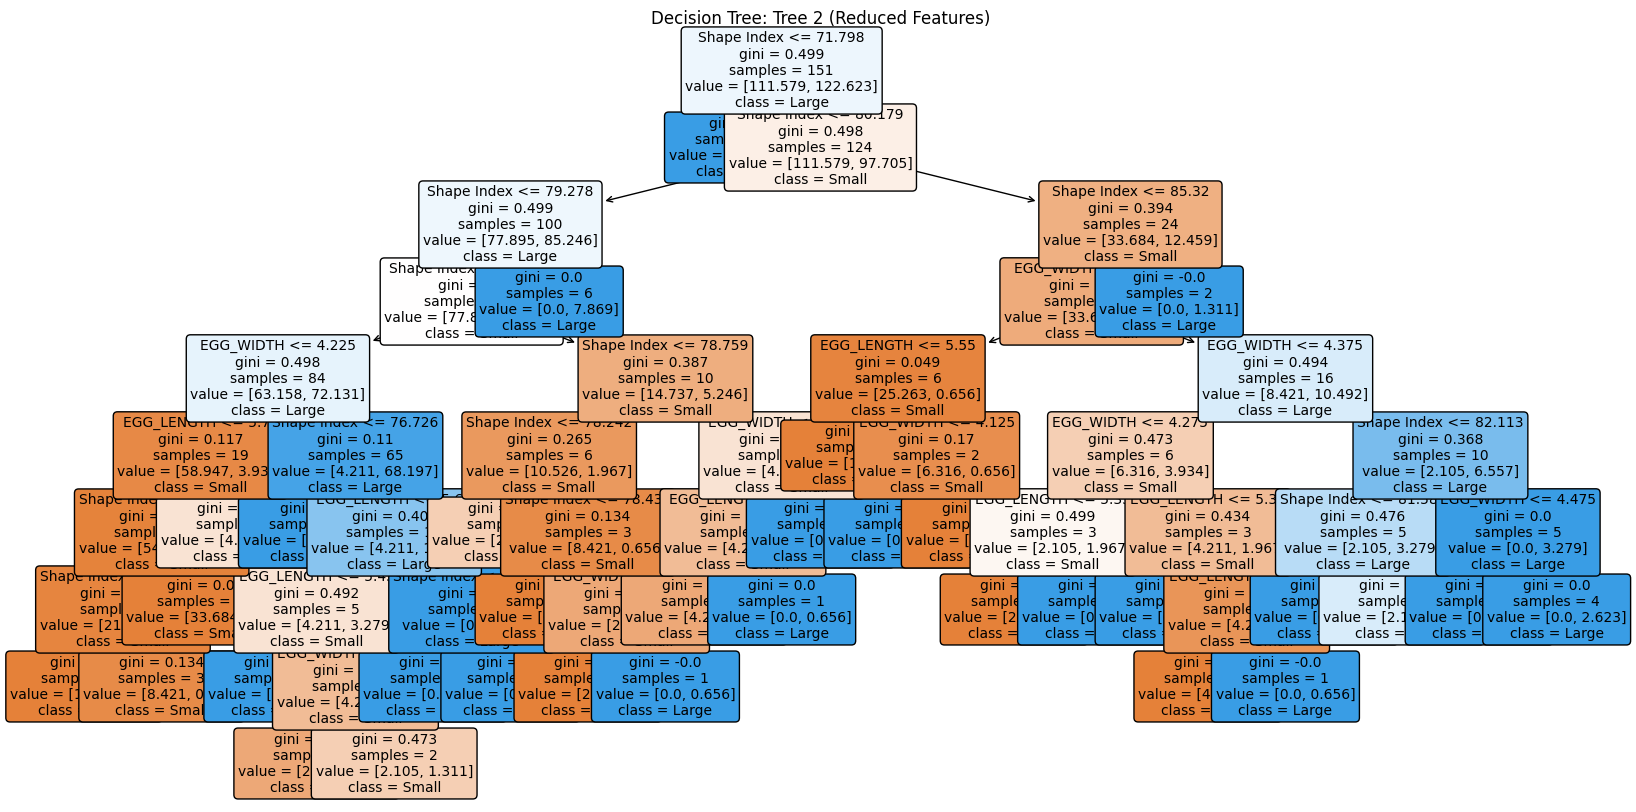

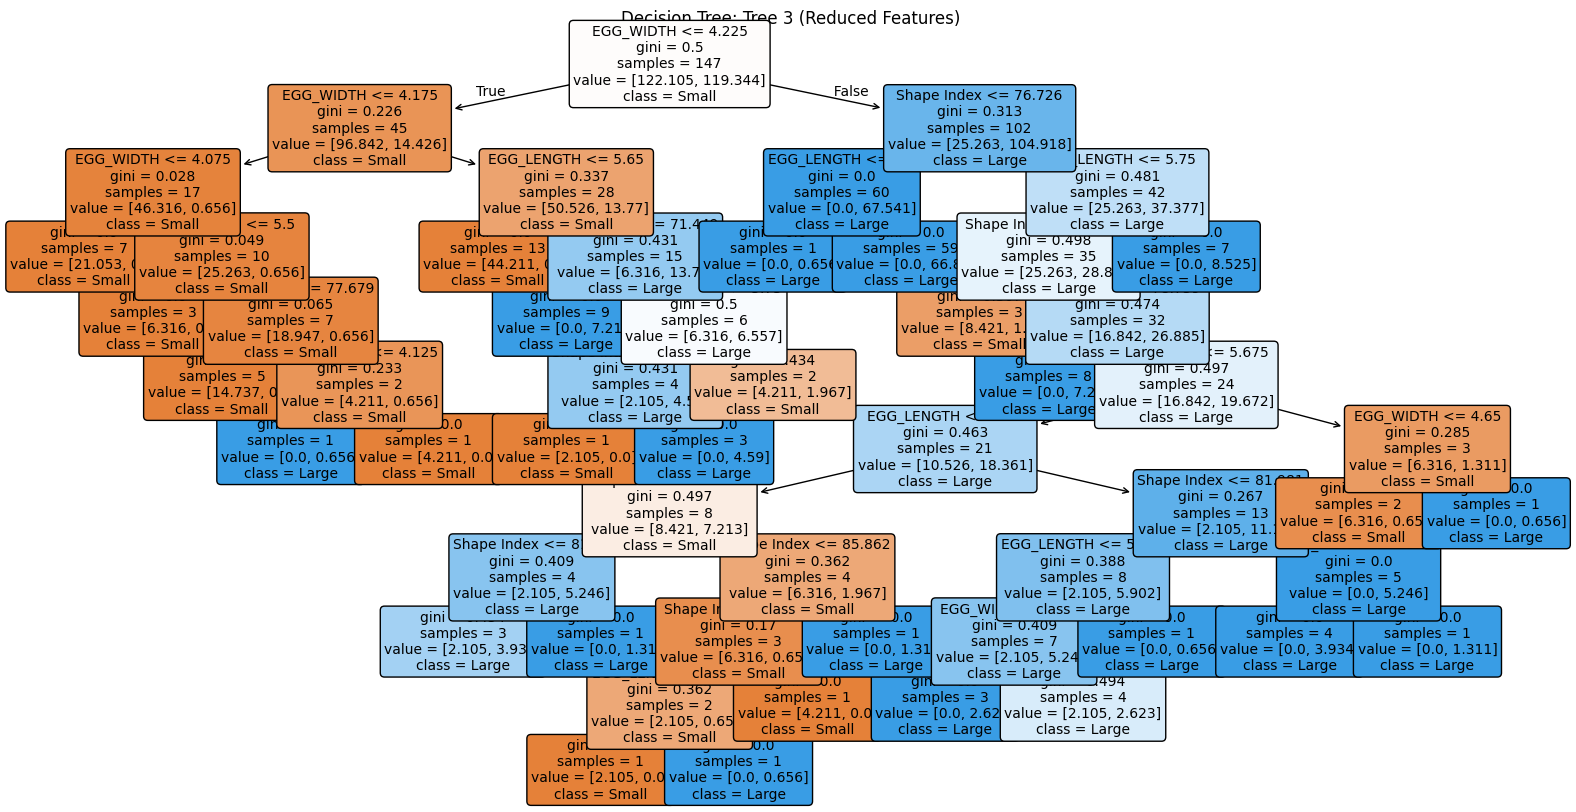

In [37]:
def plot_decision_tree(tree, tree_name, feature_names):
    plt.figure(figsize=(20,10))
    plot_tree(tree, filled=True, feature_names=feature_names, class_names=['Small', 'Large'], rounded=True, fontsize=10)
    plt.title(f"Decision Tree: {tree_name} (Reduced Features)")
    plt.show()

# Get feature names from X_train
feature_names = X_train.columns.tolist()

for i in range(3): # Plotting the first 3 trees for brevity
    tree = rf.estimators_[i]
    plot_decision_tree(tree, f"Tree {i + 1}", feature_names)

## Feature Importance Analysis (Random Forest)

Feature Importances (Random Forest):
       Feature  Importance
1    EGG_WIDTH    0.418183
0   EGG_LENGTH    0.392691
2  Shape Index    0.189126


/tmp/ipython-input-189/1787698671.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis', legend=False)


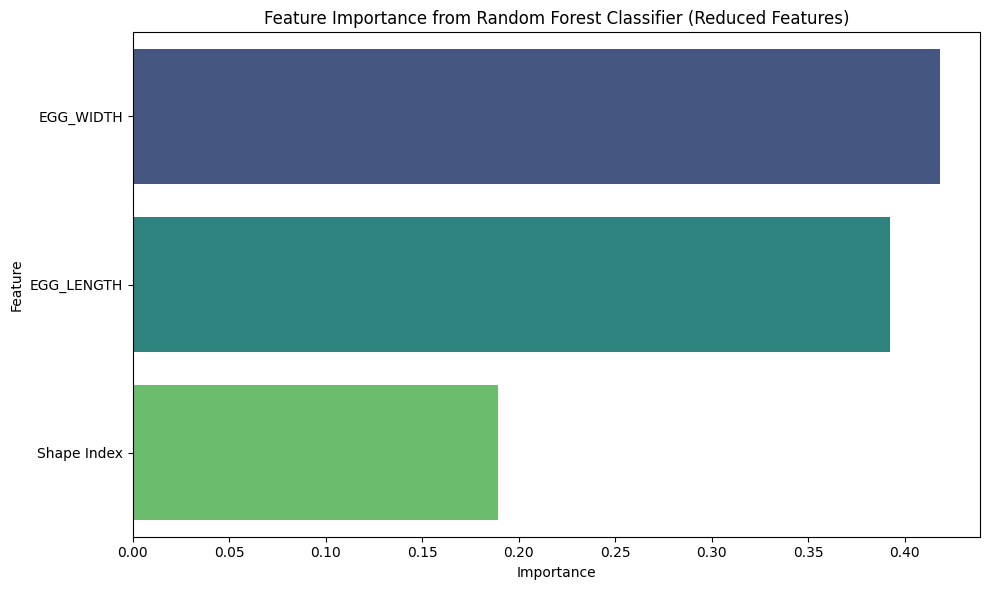

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the Random Forest model
feature_importances = rf.feature_importances_

# Get feature names from the training data
feature_names = X_train.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

# Sort the features by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importances (Random Forest):")
print(importance_df)

# Plotting the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis', legend=False)
plt.title('Feature Importance from Random Forest Classifier (Reduced Features)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

#SUPPORT VECTOR MACHINE

In [39]:
svm_model = SVC(random_state=42, class_weight='balanced', probability=True)
svm_model.fit(X_train, Y_train)
print("SVM model re-trained successfully.")

SVM model re-trained successfully.


Performance metrics for the SVM model (after removing internal egg quality traits):
SVM Accuracy: 0.65
SVM Precision: 0.8571428571428571
SVM Recall: 0.6521739130434783
SVM F1-score: 0.7407407407407407
SVM Balanced Accuracy: 0.6475155279503106
SVM ROC AUC Score: 0.8020186335403727

Classification Report for the SVM model:
              precision    recall  f1-score   support

           0       0.36      0.64      0.46        14
           1       0.86      0.65      0.74        46

    accuracy                           0.65        60
   macro avg       0.61      0.65      0.60        60
weighted avg       0.74      0.65      0.68        60


SVM Confusion Matrix:


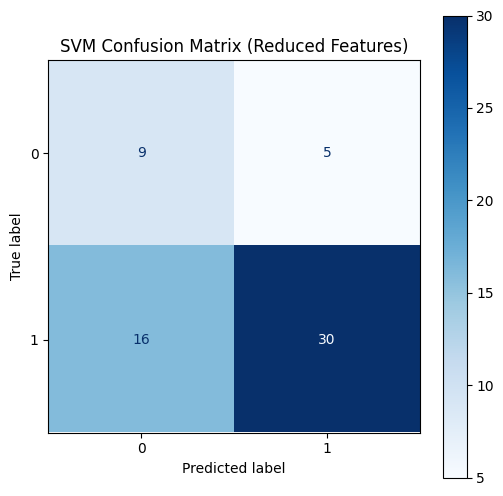

In [40]:
y_pred_svm = svm_model.predict(X_test)

print("Performance metrics for the SVM model (after removing internal egg quality traits):")
accuracy_svm = accuracy_score(Y_test, y_pred_svm)
precision_svm = precision_score(Y_test, y_pred_svm)
recall_svm = recall_score(Y_test, y_pred_svm)
f1_svm = f1_score(Y_test, y_pred_svm)
balanced_accuracy_svm = balanced_accuracy_score(Y_test, y_pred_svm)
roc_auc_svm = roc_auc_score(Y_test, svm_model.predict_proba(X_test)[:, 1])

print(f"SVM Accuracy: {accuracy_svm}")
print(f"SVM Precision: {precision_svm}")
print(f"SVM Recall: {recall_svm}")
print(f"SVM F1-score: {f1_svm}")
print(f"SVM Balanced Accuracy: {balanced_accuracy_svm}")
print(f"SVM ROC AUC Score: {roc_auc_svm}")

print("\nClassification Report for the SVM model:")
print(classification_report(Y_test, y_pred_svm))

print("\nSVM Confusion Matrix:")
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(svm_model, X_test, Y_test, cmap='Blues', ax=ax)
plt.title('SVM Confusion Matrix (Reduced Features)')
plt.show()

MAKING A PREDICTION (SVM)

In [41]:
"""Features to be inputed are:
Egg length, Egg width, Shape index) accordingly"""

EGG_data = (5.6, 4.1, 73.2)
EGG_data_as_numpy_array = np.asarray(EGG_data)
EGG_data_reshaped = EGG_data_as_numpy_array.reshape(1, -1)

print("\nPrediction using SVM:")
prediction_svm = svm_model.predict(EGG_data_reshaped)
print(prediction_svm)

if (prediction_svm[0] == 0):
  print('This egg is predicted as Small by SVM')
else:
  print('This egg is predicted as Large by SVM')


Prediction using SVM:
[1]
This egg is predicted as Large by SVM


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


### Model Performance Summary (Reduced Features)

After removing the internal egg quality traits and re-training the models with only `EGG_LENGTH`, `EGG_WIDTH`, and `Shape Index`, here's a summary of their performance:

| Model             | Accuracy | Precision | Recall | F1-Score | Balanced Accuracy | ROC AUC Score |
|:------------------|:--------:|:---------:|:------:|:--------:|:-----------------:|:-------------:|
| Logistic Regression | 0.83     | 1.00      | 0.78   | 0.88     | 0.8913            | 0.9495        |
| Random Forest     | 0.87     | 0.91      | 0.91   | 0.91     | 0.8137            | 0.9340        |
| SVM               | 0.65     | 0.86      | 0.65   | 0.74     | 0.6475            | 0.8020        |

**Observations:**

1.  **Overall Performance Degradation:** As expected, removing the internal egg quality traits generally led to a decrease in the performance of all models compared to their performance with the full feature set. This indicates that the dropped features (like yolk height, yolk width, shell thickness, etc.) were indeed important for predicting egg outcome.
2.  **Logistic Regression:** While its overall accuracy dropped from 0.95 to 0.83, its balanced accuracy and ROC AUC remained relatively strong, suggesting it still performs reasonably well despite the feature reduction. The precision for class 1 (Large) remains perfect, but recall for class 1 (Large) decreased, indicating it's missing more large eggs. Its recall for class 0 (Small) remains 1.00, meaning it identifies all small eggs correctly.
3.  **Random Forest:** This model also saw a drop in performance, with balanced accuracy falling from 0.9425 to 0.8137 and ROC AUC from 0.9946 to 0.9340. However, it still maintains a good overall accuracy of 0.87, slightly outperforming Logistic Regression in overall accuracy and F1-score for class 1. Its balanced accuracy indicates a more balanced performance across classes compared to the full feature set, although lower overall.
4.  **SVM:** The SVM model experienced the most significant drop in performance. Its accuracy plummeted from 0.80 to 0.65, and its balanced accuracy dropped from 0.8696 to 0.6475. The ROC AUC score also decreased substantially from 0.9938 to 0.8020. This suggests that SVM relies more heavily on the detailed internal egg quality features than the other two models for good classification.

**Conclusion:**

All three models demonstrated reduced performance when trained with only external egg characteristics. The Random Forest model appears to be the most robust among the three with the reduced feature set, maintaining the highest accuracy and F1-score for class 1. SVM, on the other hand, was most affected by the removal of internal features. This analysis highlights the importance of internal egg quality traits in accurately classifying egg outcomes.

## Summary:

### Q&A
The performance of all three models after removing the specified internal egg quality traits (yolk height, yolk width, shell thickness, etc.) generally degraded, indicating the importance of these features for accurate classification.

*   **Logistic Regression** saw its accuracy drop from 0.95 (with full features) to 0.83. Its balanced accuracy was 0.8913 and ROC AUC was 0.9495. While its precision for class 1 remained perfect (1.00), its recall for class 1 decreased to 0.78, suggesting it missed more large eggs. Its recall for class 0 remained high (1.00).
*   **Random Forest** also experienced a performance decline, with balanced accuracy falling from 0.9425 to 0.8137 and ROC AUC from 0.9946 to 0.9340. However, it maintained the highest overall accuracy of 0.87 among the reduced feature models, with a precision of 0.91 and recall of 0.91 for class 1. It demonstrated the most robustness to feature reduction.
*   **Support Vector Machine (SVM)** showed the most significant performance drop, with accuracy plummeting from 0.80 to 0.65. Its balanced accuracy decreased from 0.8696 to 0.6475, and ROC AUC from 0.9938 to 0.8020. This indicates a high dependency of the SVM model on the detailed internal egg quality features.

### Data Analysis Key Findings
*   All models exhibited a decrease in performance metrics (accuracy, balanced accuracy, ROC AUC) after removing internal egg quality traits and using only `EGG_LENGTH`, `EGG_WIDTH`, and `Shape Index`.
*   Logistic Regression maintained a balanced accuracy of 0.8913 and an ROC AUC of 0.9495, demonstrating reasonable performance despite feature reduction, although its overall accuracy dropped to 0.83.
*   Random Forest emerged as the most robust model with the reduced feature set, achieving the highest overall accuracy of 0.87, a balanced accuracy of 0.8137, and an ROC AUC of 0.9340.
*   SVM experienced the most substantial performance degradation, with its accuracy dropping to 0.65, balanced accuracy to 0.6475, and ROC AUC to 0.8020, highlighting its sensitivity to
